In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/YOLOV11/Datasets/ocr_dataset/ /content/

In [3]:
!cp -r /content/drive/MyDrive/YOLOV11/OCR_dataset.py /content/
!cp -r /content/drive/MyDrive/YOLOV11/tokenizer.py /content/

In [4]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 107.7 MB/s eta 0:00:00


# 1. Import Libraries

In [52]:
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch import nn
import timm
from torchvision.transforms import InterpolationMode

import json

from OCR_dataset import STRDataset
from tokenizer import encode, decode_prediction, decode_label

import matplotlib.pyplot as plt

import random
import os
import numpy as np
import re
import pandas as pd

from jiwer import cer, wer

In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

In [7]:
set_seed(0)

# 2. Prepare Dataset

In [8]:
with open("ocr_dataset/vocab.json") as f:
    vocab = json.load(f)

char_to_idx = {k: int(v) for k, v in vocab["char_to_idx"].items()}
idx_to_char = {int(k): v for k, v in vocab["idx_to_char"].items()}
chars = vocab["chars"]
blank_char = vocab["blank_char"]

In [9]:
def load_split(file):
    imgs = []
    labels = []

    with open(file) as f:
        for line in f:
            img, label = line.strip().split("\t")
            imgs.append(img)
            labels.append(label)

    return imgs, labels

In [10]:
X_train, y_train = load_split("ocr_dataset/train_labels.txt")
X_val, y_val = load_split("ocr_dataset/val_labels.txt")
X_test, y_test = load_split("ocr_dataset/test_labels.txt")

In [11]:
for i in range(len(X_train)):
  X_train[i] = X_train[i].replace("\\", "/")
  X_train[i] = X_train[i].replace("Datasets/", "")

for i in range(len(X_val)):
  X_val[i] = X_val[i].replace("\\", "/")
  X_val[i] = X_val[i].replace("Datasets/", "")

for i in range(len(X_test)):
  X_test[i] = X_test[i].replace("\\", "/")
  X_test[i] = X_test[i].replace("Datasets/", "")


In [12]:
max_label_len = max([len(label) for label in y_train + y_val + y_test])
vocab_size = len(chars)

max_label_len, vocab_size

(14, 37)

In [13]:
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((100, 420)),
            transforms.ColorJitter(
                brightness=0.5,
                contrast=0.5,
                saturation=0.5,
            ),
            transforms.Grayscale(
                num_output_channels=1,
            ),
            transforms.GaussianBlur(3),
            transforms.RandomAffine(
                degrees=1,
                shear=1,
            ),
            transforms.RandomPerspective(
                distortion_scale=0.3,
                p=0.5,
                interpolation=3,
            ),
            transforms.RandomRotation(degrees=2),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((100, 420)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
}

In [14]:
train_dataset = STRDataset(
    X_train,
    y_train,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["train"],
)
val_dataset = STRDataset(
    X_val,
    y_val,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["val"],
)
test_dataset = STRDataset(
    X_test,
    y_test,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["val"],
)

In [15]:
TRAIN_BATCH_SIZE = 64
TEST_BATCH_SIZE = 64 * 2

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

# 3. Building Model

In [17]:
class CRNN(nn.Module):
    def __init__(
        self, vocab_size, hidden_size, n_layers, dropout=0.2, unfreeze_layers=3
    ):
        super(CRNN, self).__init__()

        backbone = timm.create_model("resnet34", in_chans=1, pretrained=True)
        modules = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

        for parameter in self.backbone[-unfreeze_layers:].parameters():
            parameter.requires_grad = True

        self.mapSeq = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            512,
            hidden_size,
            n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        self.out = nn.Sequential(
            nn.Linear(hidden_size * 2, vocab_size), nn.LogSoftmax(dim=2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = x.permute(0, 3, 1, 2)
        x = x.view(x.size(0), x.size(1), -1)
        x = self.mapSeq(x)
        x, _ = self.gru(x)
        x = self.layer_norm(x)
        x = self.out(x)
        x = x.permute(1, 0, 2)

        return x

In [18]:
HIDDEN_SIZE = 256
N_LAYERS = 3
DROPOUT_PROB = 0.2
UNFREEZE_LAYERS = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
model = CRNN(
    vocab_size = vocab_size,
    hidden_size = HIDDEN_SIZE,
    n_layers = N_LAYERS,
    dropout = DROPOUT_PROB,
    unfreeze_layers = UNFREEZE_LAYERS
).to(device)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

# 4. Training

In [20]:
def evaluate(model, dataloader, criterion, device):
  model.eval()

  losses = []

  total_correct = 0
  total_samples = 0

  pred_texts = []
  gt_texts = []
  with torch.no_grad():
    for idx, (inputs, labels, labels_len) in enumerate(dataloader):
      inputs = inputs.to(device)
      labels = labels.to(device)
      labels_len = labels_len.to(device)

      outputs = model(inputs)
      logits_len = torch.full(
          size=(outputs.size(1),),
          fill_value=outputs.size(0),
          dtype=torch.long
      ).to(device)

      loss = criterion(outputs, labels, logits_len, labels_len)
      losses.append(loss.item())

      preds = outputs.argmax(dim=2)
      preds = preds.transpose(0,1)

      pred_strings = decode_prediction(
                preds.cpu(),
                idx_to_char
            )

      gt_strings = decode_label(
          labels.cpu(),
          idx_to_char
      )

      pred_texts.extend(pred_strings)
      gt_texts.extend(gt_strings)

      total_correct += sum(
          p == g
          for p, g in zip(pred_strings, gt_strings)
      )

      total_samples += len(gt_strings)

    accuracy = total_correct / total_samples

  metrics = {
      "loss": sum(losses)/len(losses),
      "accuracy": total_correct / total_samples,
      "cer": cer(gt_texts, pred_texts),
      "wer": wer(gt_texts, pred_texts),
  }

  return metrics

In [21]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    max_grad_norm=2,
):
  train_losses = []
  val_losses = []

  best_cer = float("inf")

  for epoch in range(epochs):
    batch_train_losses = []

    model.train()

    for idx, (inputs, labels, labels_len) in enumerate(train_loader):
      inputs = inputs.to(device)
      labels = labels.to(device)
      labels_len = labels_len.to(device)

      optimizer.zero_grad()
      outputs = model(inputs)

      logits_len = torch.full(
          size=(outputs.size(1),),
          fill_value=outputs.size(0),
          dtype=torch.long
      ).to(device)

      loss = criterion(outputs, labels.cpu(), logits_len.cpu(), labels_len.cpu())

      loss.backward()

      torch.nn.utils.clip_grad_norm(model.parameters(), max_grad_norm)

      optimizer.step()

      batch_train_losses.append(loss.item())

    train_loss = sum(batch_train_losses) / len(batch_train_losses)
    train_losses.append(train_loss)

    metrics = evaluate(model, val_loader, criterion, device)
    val_loss = metrics["loss"]

    val_losses.append(val_loss)

    if metrics["cer"] < best_cer:
      best_cer = metrics["cer"]
      torch.save(model.state_dict(), "best_model.pt")

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:3d} | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"CER: {metrics['cer']:.4f} | "
        f"WER: {metrics['wer']:.4f}"
    )

    scheduler.step(metrics["cer"])

  return train_losses, val_losses

In [22]:
epochs = 100
lr = 1e-3
weight_decay = 1e-5
scheduler_step_size = epochs * 0.5

criterion = nn.CTCLoss(
    blank = char_to_idx[blank_char],
    zero_infinity = True,
    reduction="mean",
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = lr,
    weight_decay = weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    threshold=1e-4,
    min_lr=1e-6,
)

In [23]:
train_losses, val_losses = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
)

/tmp/ipykernel_1763/295897599.py:40: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(model.parameters(), max_grad_norm)


Epoch   1 | LR: 1.00e-03 | Train Loss: 5.4496 | Val Loss: 3.7817 | Acc: 0.0000 | CER: 1.0000 | WER: 1.0000
Epoch   2 | LR: 1.00e-03 | Train Loss: 3.6352 | Val Loss: 3.5323 | Acc: 0.0000 | CER: 1.0000 | WER: 1.0000
Epoch   3 | LR: 1.00e-03 | Train Loss: 3.4259 | Val Loss: 3.4322 | Acc: 0.0000 | CER: 0.9841 | WER: 1.0000
Epoch   4 | LR: 1.00e-03 | Train Loss: 3.3812 | Val Loss: 3.3991 | Acc: 0.0000 | CER: 0.9788 | WER: 1.0000
Epoch   5 | LR: 1.00e-03 | Train Loss: 3.2450 | Val Loss: 3.1757 | Acc: 0.0000 | CER: 0.9700 | WER: 1.0000
Epoch   6 | LR: 1.00e-03 | Train Loss: 2.9822 | Val Loss: 2.9091 | Acc: 0.0000 | CER: 0.8183 | WER: 1.0000
Epoch   7 | LR: 1.00e-03 | Train Loss: 2.7013 | Val Loss: 2.7822 | Acc: 0.0000 | CER: 0.7619 | WER: 1.0000
Epoch   8 | LR: 1.00e-03 | Train Loss: 2.4582 | Val Loss: 2.4588 | Acc: 0.0000 | CER: 0.6737 | WER: 1.0000
Epoch   9 | LR: 1.00e-03 | Train Loss: 2.0813 | Val Loss: 2.0878 | Acc: 0.0459 | CER: 0.4903 | WER: 0.9541
Epoch  10 | LR: 1.00e-03 | Train Loss

# 5. Evaluation

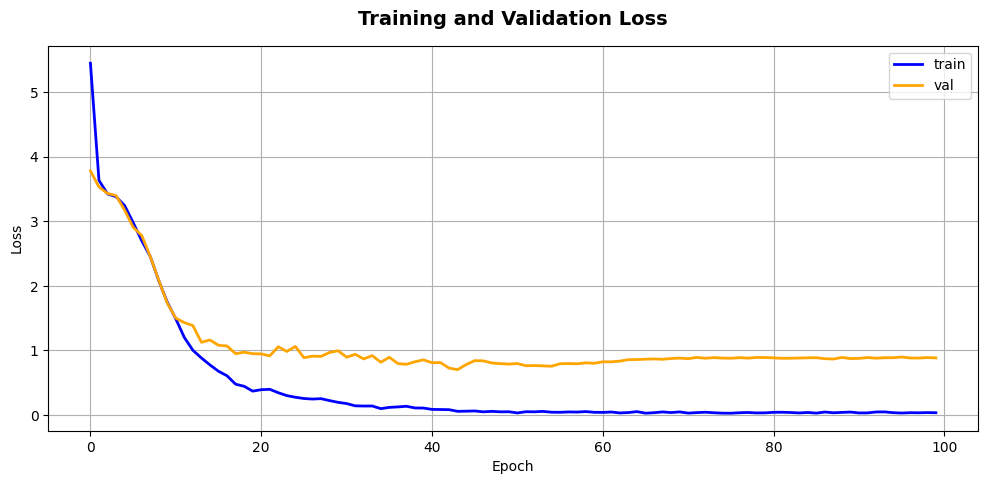

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(train_losses, label="train", color="blue", linewidth=2)
plt.plot(val_losses, label="val", color="orange", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss", fontsize=14, fontweight='bold', pad=15)
plt.grid(True)
plt.legend()
plt.show()


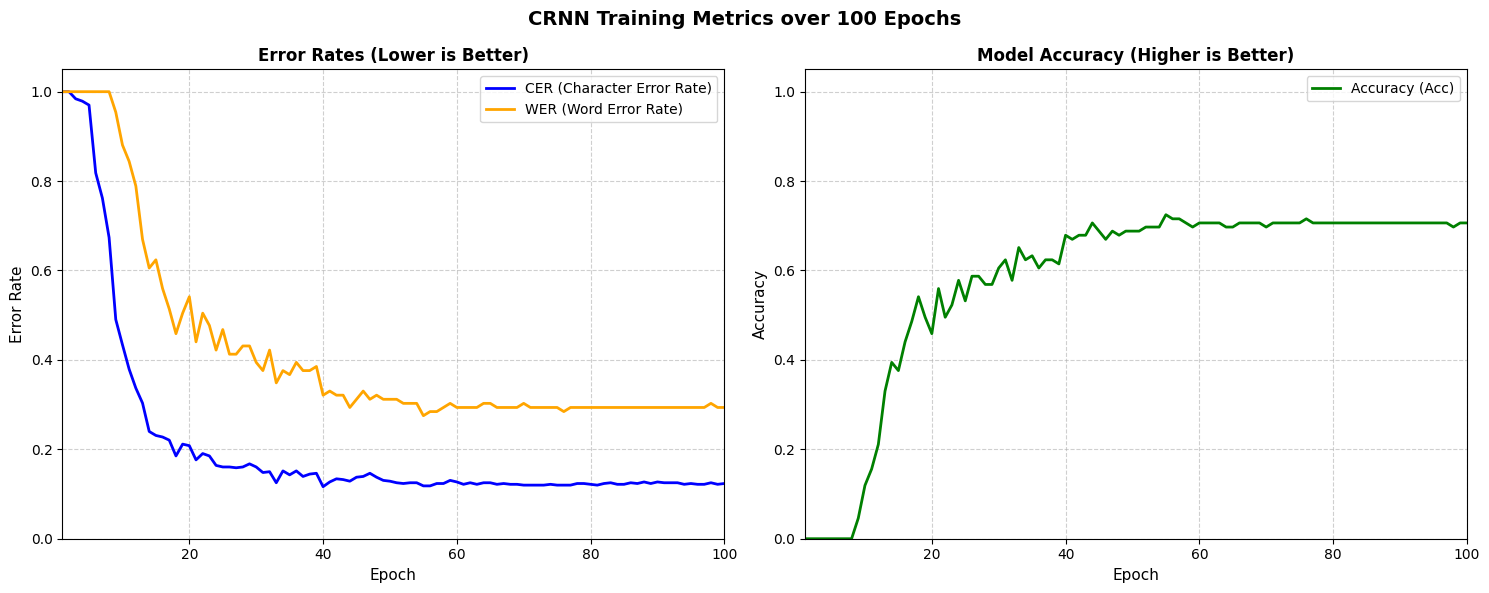

In [50]:
log_data = """
Epoch   1 | LR: 1.00e-03 | Train Loss: 5.4496 | Val Loss: 3.7817 | Acc: 0.0000 | CER: 1.0000 | WER: 1.0000
Epoch   2 | LR: 1.00e-03 | Train Loss: 3.6352 | Val Loss: 3.5323 | Acc: 0.0000 | CER: 1.0000 | WER: 1.0000
Epoch   3 | LR: 1.00e-03 | Train Loss: 3.4259 | Val Loss: 3.4322 | Acc: 0.0000 | CER: 0.9841 | WER: 1.0000
Epoch   4 | LR: 1.00e-03 | Train Loss: 3.3812 | Val Loss: 3.3991 | Acc: 0.0000 | CER: 0.9788 | WER: 1.0000
Epoch   5 | LR: 1.00e-03 | Train Loss: 3.2450 | Val Loss: 3.1757 | Acc: 0.0000 | CER: 0.9700 | WER: 1.0000
Epoch   6 | LR: 1.00e-03 | Train Loss: 2.9822 | Val Loss: 2.9091 | Acc: 0.0000 | CER: 0.8183 | WER: 1.0000
Epoch   7 | LR: 1.00e-03 | Train Loss: 2.7013 | Val Loss: 2.7822 | Acc: 0.0000 | CER: 0.7619 | WER: 1.0000
Epoch   8 | LR: 1.00e-03 | Train Loss: 2.4582 | Val Loss: 2.4588 | Acc: 0.0000 | CER: 0.6737 | WER: 1.0000
Epoch   9 | LR: 1.00e-03 | Train Loss: 2.0813 | Val Loss: 2.0878 | Acc: 0.0459 | CER: 0.4903 | WER: 0.9541
Epoch  10 | LR: 1.00e-03 | Train Loss: 1.7472 | Val Loss: 1.7327 | Acc: 0.1193 | CER: 0.4339 | WER: 0.8807
Epoch  11 | LR: 1.00e-03 | Train Loss: 1.4881 | Val Loss: 1.5009 | Acc: 0.1560 | CER: 0.3792 | WER: 0.8440
Epoch  12 | LR: 1.00e-03 | Train Loss: 1.2004 | Val Loss: 1.4310 | Acc: 0.2110 | CER: 0.3369 | WER: 0.7890
Epoch  13 | LR: 1.00e-03 | Train Loss: 1.0024 | Val Loss: 1.3854 | Acc: 0.3303 | CER: 0.3034 | WER: 0.6697
Epoch  14 | LR: 1.00e-03 | Train Loss: 0.8835 | Val Loss: 1.1268 | Acc: 0.3945 | CER: 0.2399 | WER: 0.6055
Epoch  15 | LR: 1.00e-03 | Train Loss: 0.7755 | Val Loss: 1.1622 | Acc: 0.3761 | CER: 0.2310 | WER: 0.6239
Epoch  16 | LR: 1.00e-03 | Train Loss: 0.6772 | Val Loss: 1.0802 | Acc: 0.4404 | CER: 0.2275 | WER: 0.5596
Epoch  17 | LR: 1.00e-03 | Train Loss: 0.6073 | Val Loss: 1.0688 | Acc: 0.4862 | CER: 0.2205 | WER: 0.5138
Epoch  18 | LR: 1.00e-03 | Train Loss: 0.4775 | Val Loss: 0.9496 | Acc: 0.5413 | CER: 0.1852 | WER: 0.4587
Epoch  19 | LR: 1.00e-03 | Train Loss: 0.4448 | Val Loss: 0.9728 | Acc: 0.4954 | CER: 0.2116 | WER: 0.5046
Epoch  20 | LR: 1.00e-03 | Train Loss: 0.3698 | Val Loss: 0.9497 | Acc: 0.4587 | CER: 0.2081 | WER: 0.5413
Epoch  21 | LR: 1.00e-03 | Train Loss: 0.3923 | Val Loss: 0.9470 | Acc: 0.5596 | CER: 0.1764 | WER: 0.4404
Epoch  22 | LR: 1.00e-03 | Train Loss: 0.3979 | Val Loss: 0.9161 | Acc: 0.4954 | CER: 0.1905 | WER: 0.5046
Epoch  23 | LR: 1.00e-03 | Train Loss: 0.3451 | Val Loss: 1.0569 | Acc: 0.5229 | CER: 0.1852 | WER: 0.4771
Epoch  24 | LR: 1.00e-03 | Train Loss: 0.3003 | Val Loss: 0.9843 | Acc: 0.5780 | CER: 0.1640 | WER: 0.4220
Epoch  25 | LR: 1.00e-03 | Train Loss: 0.2749 | Val Loss: 1.0618 | Acc: 0.5321 | CER: 0.1605 | WER: 0.4679
Epoch  26 | LR: 1.00e-03 | Train Loss: 0.2559 | Val Loss: 0.8876 | Acc: 0.5872 | CER: 0.1605 | WER: 0.4128
Epoch  27 | LR: 1.00e-03 | Train Loss: 0.2471 | Val Loss: 0.9117 | Acc: 0.5872 | CER: 0.1587 | WER: 0.4128
Epoch  28 | LR: 1.00e-03 | Train Loss: 0.2533 | Val Loss: 0.9075 | Acc: 0.5688 | CER: 0.1605 | WER: 0.4312
Epoch  29 | LR: 1.00e-03 | Train Loss: 0.2233 | Val Loss: 0.9687 | Acc: 0.5688 | CER: 0.1675 | WER: 0.4312
Epoch  30 | LR: 1.00e-03 | Train Loss: 0.1962 | Val Loss: 0.9952 | Acc: 0.6055 | CER: 0.1605 | WER: 0.3945
Epoch  31 | LR: 1.00e-03 | Train Loss: 0.1774 | Val Loss: 0.8950 | Acc: 0.6239 | CER: 0.1481 | WER: 0.3761
Epoch  32 | LR: 1.00e-03 | Train Loss: 0.1422 | Val Loss: 0.9405 | Acc: 0.5780 | CER: 0.1499 | WER: 0.4220
Epoch  33 | LR: 1.00e-03 | Train Loss: 0.1391 | Val Loss: 0.8692 | Acc: 0.6514 | CER: 0.1252 | WER: 0.3486
Epoch  34 | LR: 1.00e-03 | Train Loss: 0.1396 | Val Loss: 0.9201 | Acc: 0.6239 | CER: 0.1517 | WER: 0.3761
Epoch  35 | LR: 1.00e-03 | Train Loss: 0.0984 | Val Loss: 0.8174 | Acc: 0.6330 | CER: 0.1429 | WER: 0.3670
Epoch  36 | LR: 1.00e-03 | Train Loss: 0.1181 | Val Loss: 0.8941 | Acc: 0.6055 | CER: 0.1517 | WER: 0.3945
Epoch  37 | LR: 1.00e-03 | Train Loss: 0.1254 | Val Loss: 0.7972 | Acc: 0.6239 | CER: 0.1393 | WER: 0.3761
Epoch  38 | LR: 1.00e-03 | Train Loss: 0.1352 | Val Loss: 0.7847 | Acc: 0.6239 | CER: 0.1446 | WER: 0.3761
Epoch  39 | LR: 1.00e-03 | Train Loss: 0.1095 | Val Loss: 0.8250 | Acc: 0.6147 | CER: 0.1464 | WER: 0.3853
Epoch  40 | LR: 5.00e-04 | Train Loss: 0.1077 | Val Loss: 0.8540 | Acc: 0.6789 | CER: 0.1164 | WER: 0.3211
Epoch  41 | LR: 5.00e-04 | Train Loss: 0.0871 | Val Loss: 0.8101 | Acc: 0.6697 | CER: 0.1270 | WER: 0.3303
Epoch  42 | LR: 5.00e-04 | Train Loss: 0.0851 | Val Loss: 0.8117 | Acc: 0.6789 | CER: 0.1340 | WER: 0.3211
Epoch  43 | LR: 5.00e-04 | Train Loss: 0.0826 | Val Loss: 0.7264 | Acc: 0.6789 | CER: 0.1323 | WER: 0.3211
Epoch  44 | LR: 5.00e-04 | Train Loss: 0.0569 | Val Loss: 0.7029 | Acc: 0.7064 | CER: 0.1287 | WER: 0.2936
Epoch  45 | LR: 5.00e-04 | Train Loss: 0.0591 | Val Loss: 0.7817 | Acc: 0.6881 | CER: 0.1376 | WER: 0.3119
Epoch  46 | LR: 5.00e-04 | Train Loss: 0.0628 | Val Loss: 0.8421 | Acc: 0.6697 | CER: 0.1393 | WER: 0.3303
Epoch  47 | LR: 2.50e-04 | Train Loss: 0.0495 | Val Loss: 0.8391 | Acc: 0.6881 | CER: 0.1464 | WER: 0.3119
Epoch  48 | LR: 2.50e-04 | Train Loss: 0.0566 | Val Loss: 0.8064 | Acc: 0.6789 | CER: 0.1376 | WER: 0.3211
Epoch  49 | LR: 2.50e-04 | Train Loss: 0.0493 | Val Loss: 0.7958 | Acc: 0.6881 | CER: 0.1305 | WER: 0.3119
Epoch  50 | LR: 2.50e-04 | Train Loss: 0.0506 | Val Loss: 0.7888 | Acc: 0.6881 | CER: 0.1287 | WER: 0.3119
Epoch  51 | LR: 2.50e-04 | Train Loss: 0.0321 | Val Loss: 0.7971 | Acc: 0.6881 | CER: 0.1252 | WER: 0.3119
Epoch  52 | LR: 2.50e-04 | Train Loss: 0.0512 | Val Loss: 0.7630 | Acc: 0.6972 | CER: 0.1235 | WER: 0.3028
Epoch  53 | LR: 1.25e-04 | Train Loss: 0.0494 | Val Loss: 0.7661 | Acc: 0.6972 | CER: 0.1252 | WER: 0.3028
Epoch  54 | LR: 1.25e-04 | Train Loss: 0.0559 | Val Loss: 0.7612 | Acc: 0.6972 | CER: 0.1252 | WER: 0.3028
Epoch  55 | LR: 1.25e-04 | Train Loss: 0.0433 | Val Loss: 0.7557 | Acc: 0.7248 | CER: 0.1182 | WER: 0.2752
Epoch  56 | LR: 1.25e-04 | Train Loss: 0.0420 | Val Loss: 0.7947 | Acc: 0.7156 | CER: 0.1182 | WER: 0.2844
Epoch  57 | LR: 1.25e-04 | Train Loss: 0.0476 | Val Loss: 0.7965 | Acc: 0.7156 | CER: 0.1235 | WER: 0.2844
Epoch  58 | LR: 1.25e-04 | Train Loss: 0.0456 | Val Loss: 0.7941 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  59 | LR: 6.25e-05 | Train Loss: 0.0532 | Val Loss: 0.8082 | Acc: 0.6972 | CER: 0.1305 | WER: 0.3028
Epoch  60 | LR: 6.25e-05 | Train Loss: 0.0419 | Val Loss: 0.8015 | Acc: 0.7064 | CER: 0.1270 | WER: 0.2936
Epoch  61 | LR: 6.25e-05 | Train Loss: 0.0405 | Val Loss: 0.8241 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  62 | LR: 6.25e-05 | Train Loss: 0.0461 | Val Loss: 0.8240 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  63 | LR: 6.25e-05 | Train Loss: 0.0320 | Val Loss: 0.8348 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  64 | LR: 6.25e-05 | Train Loss: 0.0381 | Val Loss: 0.8575 | Acc: 0.6972 | CER: 0.1252 | WER: 0.3028
Epoch  65 | LR: 3.13e-05 | Train Loss: 0.0525 | Val Loss: 0.8589 | Acc: 0.6972 | CER: 0.1252 | WER: 0.3028
Epoch  66 | LR: 3.13e-05 | Train Loss: 0.0284 | Val Loss: 0.8648 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  67 | LR: 3.13e-05 | Train Loss: 0.0358 | Val Loss: 0.8685 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  68 | LR: 3.13e-05 | Train Loss: 0.0476 | Val Loss: 0.8632 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  69 | LR: 3.13e-05 | Train Loss: 0.0378 | Val Loss: 0.8752 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  70 | LR: 3.13e-05 | Train Loss: 0.0479 | Val Loss: 0.8815 | Acc: 0.6972 | CER: 0.1199 | WER: 0.3028
Epoch  71 | LR: 1.56e-05 | Train Loss: 0.0295 | Val Loss: 0.8727 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  72 | LR: 1.56e-05 | Train Loss: 0.0370 | Val Loss: 0.8922 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  73 | LR: 1.56e-05 | Train Loss: 0.0430 | Val Loss: 0.8792 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  74 | LR: 1.56e-05 | Train Loss: 0.0349 | Val Loss: 0.8887 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  75 | LR: 1.56e-05 | Train Loss: 0.0287 | Val Loss: 0.8819 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  76 | LR: 1.56e-05 | Train Loss: 0.0277 | Val Loss: 0.8794 | Acc: 0.7156 | CER: 0.1199 | WER: 0.2844
Epoch  77 | LR: 7.81e-06 | Train Loss: 0.0350 | Val Loss: 0.8881 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  78 | LR: 7.81e-06 | Train Loss: 0.0391 | Val Loss: 0.8814 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  79 | LR: 7.81e-06 | Train Loss: 0.0324 | Val Loss: 0.8919 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  80 | LR: 7.81e-06 | Train Loss: 0.0337 | Val Loss: 0.8907 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  81 | LR: 7.81e-06 | Train Loss: 0.0416 | Val Loss: 0.8851 | Acc: 0.7064 | CER: 0.1199 | WER: 0.2936
Epoch  82 | LR: 7.81e-06 | Train Loss: 0.0427 | Val Loss: 0.8782 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  83 | LR: 3.91e-06 | Train Loss: 0.0387 | Val Loss: 0.8798 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  84 | LR: 3.91e-06 | Train Loss: 0.0320 | Val Loss: 0.8828 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  85 | LR: 3.91e-06 | Train Loss: 0.0394 | Val Loss: 0.8862 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  86 | LR: 3.91e-06 | Train Loss: 0.0291 | Val Loss: 0.8872 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  87 | LR: 3.91e-06 | Train Loss: 0.0461 | Val Loss: 0.8723 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  88 | LR: 3.91e-06 | Train Loss: 0.0345 | Val Loss: 0.8674 | Acc: 0.7064 | CER: 0.1270 | WER: 0.2936
Epoch  89 | LR: 1.95e-06 | Train Loss: 0.0405 | Val Loss: 0.8916 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  90 | LR: 1.95e-06 | Train Loss: 0.0454 | Val Loss: 0.8744 | Acc: 0.7064 | CER: 0.1270 | WER: 0.2936
Epoch  91 | LR: 1.95e-06 | Train Loss: 0.0320 | Val Loss: 0.8771 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  92 | LR: 1.95e-06 | Train Loss: 0.0330 | Val Loss: 0.8900 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  93 | LR: 1.95e-06 | Train Loss: 0.0467 | Val Loss: 0.8801 | Acc: 0.7064 | CER: 0.1252 | WER: 0.2936
Epoch  94 | LR: 1.95e-06 | Train Loss: 0.0482 | Val Loss: 0.8873 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  95 | LR: 1.00e-06 | Train Loss: 0.0359 | Val Loss: 0.8876 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
Epoch  96 | LR: 1.00e-06 | Train Loss: 0.0305 | Val Loss: 0.8981 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  97 | LR: 1.00e-06 | Train Loss: 0.0360 | Val Loss: 0.8830 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch  98 | LR: 1.00e-06 | Train Loss: 0.0345 | Val Loss: 0.8819 | Acc: 0.6972 | CER: 0.1252 | WER: 0.3028
Epoch  99 | LR: 1.00e-06 | Train Loss: 0.0375 | Val Loss: 0.8898 | Acc: 0.7064 | CER: 0.1217 | WER: 0.2936
Epoch 100 | LR: 1.00e-06 | Train Loss: 0.0350 | Val Loss: 0.8846 | Acc: 0.7064 | CER: 0.1235 | WER: 0.2936
"""

epochs = []
acc_values = []
cer_values = []
wer_values = []

pattern = r"Epoch\s+(\d+)\s+\|.*Acc:\s+([\d.]+)\s+\|\s+CER:\s+([\d.]+)\s+\|\s+WER:\s+([\d.]+)"

for line in log_data.strip().split('\n'):
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        acc_values.append(float(match.group(2)))
        cer_values.append(float(match.group(3)))
        wer_values.append(float(match.group(4)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(epochs, cer_values, label='CER (Character Error Rate)', color='blue', linewidth=2)
ax1.plot(epochs, wer_values, label='WER (Word Error Rate)', color='orange', linewidth=2)
ax1.set_title('Error Rates (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Error Rate', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)
ax1.set_xlim(1, 100)
ax1.set_ylim(0, 1.05)

ax2.plot(epochs, acc_values, label='Accuracy (Acc)', color='green', linewidth=2)
ax2.set_title('Model Accuracy (Higher is Better)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)
ax2.set_xlim(1, 100)
ax2.set_ylim(0, 1.05)

plt.suptitle('CRNN Training Metrics over 100 Epochs', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [34]:
final_model = CRNN(
    vocab_size = vocab_size,
    hidden_size = HIDDEN_SIZE,
    n_layers = N_LAYERS,
    dropout = DROPOUT_PROB,
    unfreeze_layers = UNFREEZE_LAYERS
).to(device)

final_model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [54]:
test_metrics = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)

pd.DataFrame(test_metrics, index=["Test"])

,loss,accuracy,cer,wer
Test,1.250295,0.642857,0.131687,0.357143


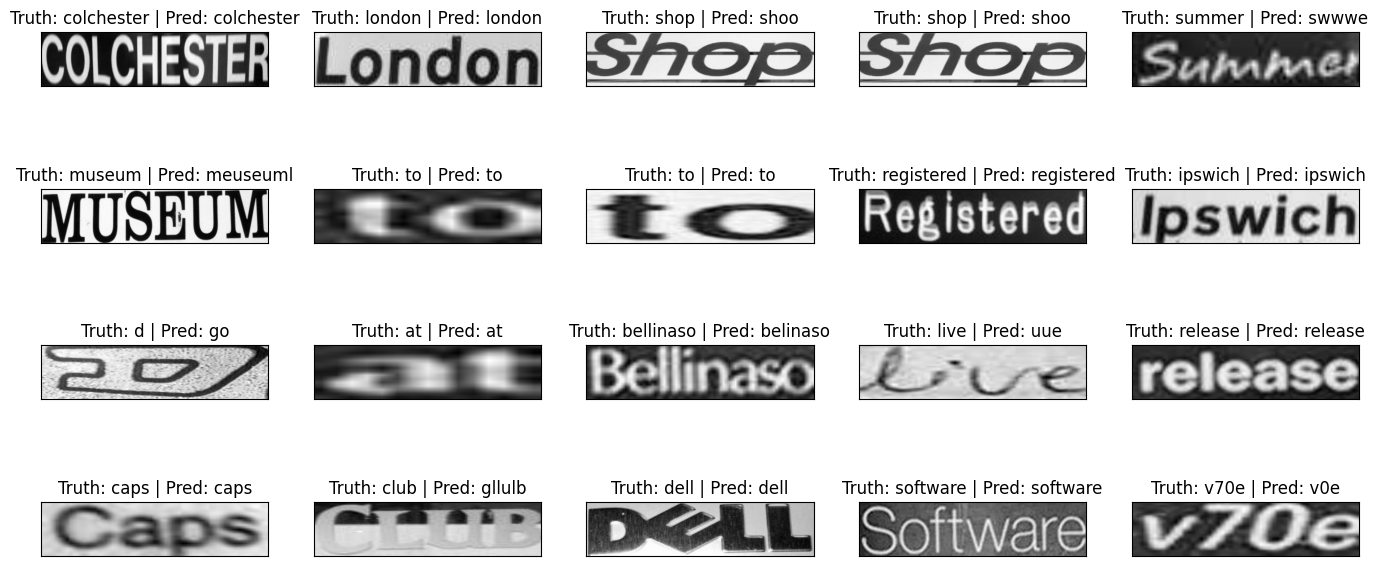

In [40]:
final_model.eval()
# view samples
sample_result = []

for i in range(50):
    idx = np.random.randint(len(test_dataset))
    img, label, label_len = test_dataset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_to_char)[0]
    logits = final_model(img.unsqueeze(0))

    pred_text = decode_prediction(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(20):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()